# Watches as an asset class — a quantitative teardown 🔬
### Resale index vs SPY (CAGR / vol / MDD + an annual-excess *t*) · Newey-West proxy alpha · the dealer-spread + carry haircut on NAV · a synthetic bubble positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Watches_beat_the_S%26P%3F: Busted](https://img.shields.io/badge/Watches_beat_the_S%26P%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "luxury watches beat the S&P": (H₁) the secondary-market resale index out-returns SPY risk-adjusted; (H₂) a buyable proxy carries alpha vs the market; (H₃) it survives the transaction + carry cost of owning physical watches. We find **H₁ rejected** (it *under*-performs), **H₂ rejected** (no significant alpha), **H₃ rejected** (negative net of costs).

> ⚠️ **Not investment advice — data provenance.** The resale index is **hardcoded, cited, approximate** (public WatchCharts / Morgan Stanley×WatchCharts reporting — a *labelled proxy*, never the live feed). Equity proxies `WOSG.L`, `CFR.SW`, `SPY` are month-end Adj Close via yfinance (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from watch_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_resale_index()                       # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| resale-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2018 → 2025', 'idx_levels': {2018: 100, 2019: 112, 2020: 130, 2021: 196, 2022: 168, 2023: 150, 2024: 141, 2025: 148}, 'idx_yoy': {2019: 12.0, 2020: 16.1, 2021: 50.8, 2022: -14.3, 2023: -10.7, 2024: -6.0, 2025: 5.0}, 'peak_date': '2022-03', 'peak_level': 220, 'peak_avg_price': 45108, 'peak_trough': -35.9, 'idx_cagr': 5.76, 'idx_vol': 22.2, 'idx_sharpe': 0.34, 'idx_mdd': -28.1, 'spy_cagr_ye': 15.03, 'spy_vol_ye': 17.5, 'spy_mdd_ye': -18.3, 'excess_mean': -9.52, 'excess_t': -1.054, 'excess_p': 0.34, 'excess_n': 6, 'wosg_cagr': 6.76, 'wosg_vol': 55.2, 'wosg_sharpe': 0.41, 'wosg_mdd': -77.0, 'wosg_alpha': -11.22, 'wosg_beta': 2.05, 'wosg_t': -0.7, 'wosg_p': 0.488, 'wosg_n': 79, 'cfr_cagr': 17.07, 'cfr_vol': 32.8, 'cfr_sharpe': 0.64, 'cfr_mdd': -36.3, 'cfr_alpha': 3.9, 'cfr_beta': 1.04, 'cfr_t': 0.41, 'cfr_p': 0.684, 'cfr_n': 83, 'spy_cagr': 16.06, 'spy_vol': 16.7, 'spy_sharpe': 0.98, 'spy_mdd': -24.0, 'carry_gross': 5.76, 'carry_spread': -7.17, 'carry_insure': -1.0, 'carry_net': -2.8, 'syn_peak': 1015, 'syn_end': 313, 'syn_cagr': 15.88, 'syn_sharpe': 0.81, 'syn_mdd': -69.2}


equity-proxy cache present: True | resale-index years: 2018 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Resale index CAGR **5.8%** vs SPY **15.0%** (2018–2025); mean annual excess **-9.5%/yr**, *t* = **-1.05** (n=6). Proxies: no significant alpha (WOSG NW *t*=-0.70, CFR *t*=+0.41). |
| **Tradability** | `MIRAGE` | Gross index CAGR **+5.8%** → **NET -2.8%/yr** after a 20% dealer spread + 1%/yr carry. Buyable proxy WOSG.L maxDD **-77%**, β≈2.0. Illiquid, high-carry, round-tripped. |
| **Watches beat the S&P?** | `BUSTED` | SPY wins CAGR (16.1 vs 5.8), Sharpe (0.98 vs 0.34), maxDD (-18 vs -28), and net-of-cost. Every column. |

> 💡 In plain words: the watch market under-performed stocks with more risk, the only thing you can buy is alpha-free beta, and the physical-flip frictions turn even the gross return negative. There is no axis on which "watches beat the S&P" survives.

## 1 · The claim, steelmanned

Let the secondary-market index level be $I_t$ and the benchmark $B_t$ (SPY). The claim is a joint hypothesis:

- **H₁ (it out-returns).** Annual excess $\;x_t = r^I_t - r^B_t\;$ has $\mathbb{E}[x_t] > 0$ with $t > 2$ — watches beat stocks *risk-adjusted*.
- **H₂ (it's buyable with alpha).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₃ (it survives carry).** The net CAGR after the dealer round-trip spread $s$ over hold $h$ and annual carry $c$ stays positive: $(1+g)(1+((1-s)^{1/h}-1))(1-c)-1 > 0$.

The 2020–22 melt-up is the steelman: for ~18 months H₁ held *in-sample*. The test is whether it holds over the **full cycle, risk-adjusted, net of cost** — i.e. whether it's an asset class or a bubble.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, watches would be a genuine diversifier: equity-beating return, wearable, low-correlation, inflation-proof — the exact pitch. But each leg is separately falsifiable. H₁ is a **return race** on a common clock. H₂ asks whether the *only investable expression* (listed equities) delivers anything beyond market beta — because you cannot custody "the index." H₃ is the **microstructure tax**: a physical watch has a ~20% bid/ask round-trip and a multi-year holding period with insurance and servicing carry, frictions an ETF never pays. The asset-class claim needs all three; failing any one downgrades it to a bubble narrative.

## 3 · How we'd know — the protocol

- **Resale index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2018), reconstructed from public WatchCharts / Morgan Stanley×WatchCharts / press figures (March-2022 top; full-year −10.7%/−6.1%/+4.9% for 2023/24/25). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed.
- **Equity proxies.** `WOSG.L`, `CFR.SW`, `SPY` month-end Adj Close (yfinance, cached). Survivorship is **not** a concern here (named tickers, not a screen), but the WOSG.L series starts at its **2019-05 IPO** — a real look-ahead caveat (we only see the listed life), stated.
- **Signal test.** (i) Paired annual-excess $t$ of $r^I - r^B$ (small-$n$, weak by construction). (ii) **Newey-West (6-lag) HAC** $t$ of the proxy alpha vs SPY — the bar for `REAL` is *t* ≥ 2 in the watches' favour.
- **Cost (beat 6).** Charge the dealer round-trip spread (20% over a 3y hold) + 1%/yr carry **once on NAV**; net CAGR.
- **Positive control.** A deterministic bubble-and-round-trip path with a *planted* boom/bust drift; the engine must recover the up-sign and a finite Sharpe — proof a null on the real tape is a real null, not a broken harness.
- **What would make us say "asset class":** H₁ *t* > 2 **or** a proxy alpha *t* > 2, **and** a positive net-of-cost CAGR. We find none of these.

## 4 · The teardown

### 4a · The race — resale index vs SPY, risk-adjusted

Year-end levels rebased to \$100, both series on one clock. CAGR, vol and max-drawdown in the print.

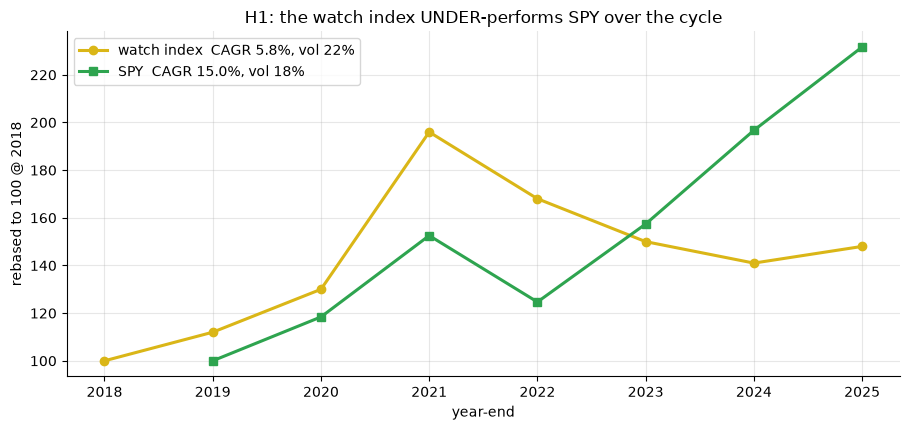

index: CAGR 5.76%  vol 22.2%  maxDD -28.1%
SPY  : CAGR 15.03%  vol 17.5%  maxDD -18.3%
annual excess (idx-SPY): mean -9.52%/yr  t=-1.054  (n=6)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
if HAVE_PROXIES:
    spy_ye = PROX['SPY'].resample('YE').last()
    spy_ye = spy_ye[(spy_ye.index.year>=2018)&(spy_ye.index.year<=2025)]
    spy = (spy_ye/spy_ye.iloc[0]*100).values; sx=[d.year for d in spy_ye.index]
    si = st.summarize(IDX, periods_per_year=1.0)
    ss = st.summarize(spy_ye, periods_per_year=1.0)
    ae = st.annual_excess_t(IDX, PROX['SPY'])
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2018) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    ae={'mean_excess':R['excess_mean']/100,'t':R['excess_t'],'n':R['excess_n']}
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"watch index  CAGR {si['cagr']*100:.1f}%, vol {si['vol']*100:.0f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.2, label=f"SPY  CAGR {ss['cagr']*100:.1f}%, vol {ss['vol']*100:.0f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2018')
ax.set_title('H1: the watch index UNDER-performs SPY over the cycle'); ax.legend()
plt.tight_layout(); plt.show()
print(f"index: CAGR {si['cagr']*100:.2f}%  vol {si['vol']*100:.1f}%  maxDD {si['mdd']*100:.1f}%")
print(f"SPY  : CAGR {ss['cagr']*100:.2f}%  vol {ss['vol']*100:.1f}%  maxDD {ss['mdd']*100:.1f}%")
print(f"annual excess (idx-SPY): mean {ae['mean_excess']*100:+.2f}%/yr  t={ae['t']:+.3f}  (n={ae['n']})")

> 💡 In plain words: the watch index compounds at **5.8%** against SPY's **15.0%**, with *higher* vol and a *deeper* drawdown — it loses on every axis. The mean annual excess is **-9.5%/yr**, *t* = **-1.05** (n=6): not even a *clean* loss given 6 annual points, but certainly **no evidence of out-performance**. H₁ rejected; the honest stamp is `NONE`, leaning negative.

### 4b · The buyable proxies — is there alpha, or just beta?

Newey-West (6-lag) regression of each proxy's **monthly** return on SPY. `REAL` needs $t_\alpha \ge 2$ in the watches' favour.

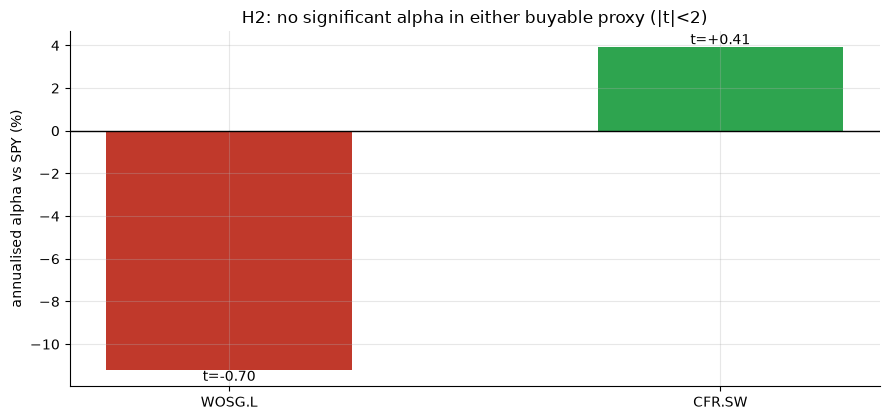

WOSG.L  CAGR   6.76%  Sharpe 0.41  maxDD  -77.0%  alpha -11.22%/yr  beta 2.05  NW t -0.70
CFR.SW  CAGR  17.07%  Sharpe 0.64  maxDD  -36.3%  alpha +3.90%/yr  beta 1.04  NW t +0.41


In [3]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['WOSG.L','CFR.SW']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'WOSG.L':dict(cagr=R['wosg_cagr'],sharpe=R['wosg_sharpe'],mdd=R['wosg_mdd'],alpha=R['wosg_alpha'],beta=R['wosg_beta'],t=R['wosg_t']),
            'CFR.SW':dict(cagr=R['cfr_cagr'],sharpe=R['cfr_sharpe'],mdd=R['cfr_mdd'],alpha=R['cfr_alpha'],beta=R['cfr_beta'],t=R['cfr_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H2: no significant alpha in either buyable proxy (|t|<2)')
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:6.2f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: Watches of Switzerland is **β≈2.0** beta with a **-11%/yr** (insignificant, *t*=-0.70) alpha and a **-77%** drawdown — it amplified the bubble, it didn't hedge it. Richemont is essentially SPY at higher vol (*t*=+0.41). **Neither clears *t* ≥ 2** in either direction: H₂ rejected. The only investable expression of the trade is market beta you could have bought cheaper as SPY.

### 4c · The microstructure tax — net of the dealer spread + carry

A physical flip pays a ~20% round-trip spread over a ~3-year hold plus ~1%/yr carry. Charge it once on the index's gross CAGR (a *generous* read — it ignores that the index level itself is mid-market, not net-to-seller).

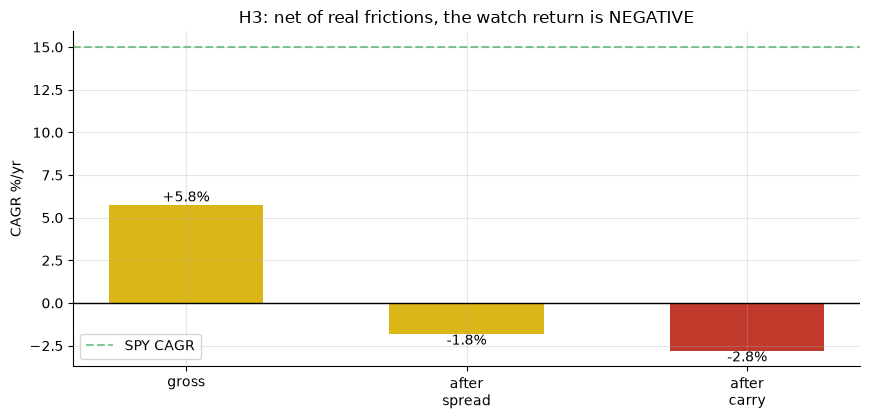

gross +5.76%  - spread -7.17%/yr  - carry -1.00%/yr  =  NET -2.80%/yr


In [4]:
h = st.net_of_carry_cagr(si['cagr'], round_trip_spread=0.20, hold_years=3.0, insure_per_year=0.01)
steps = ['gross','after\nspread','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(8.8,4.3))
cols=[AMBER, AMBER, (RED if running[-1]<0 else GREEN)]
ax.bar(steps, running, .55, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.6, label='SPY CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H3: net of real frictions, the watch return is NEGATIVE'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  - spread {h['spread_drag_annual']*100:+.2f}%/yr  - carry {h['insure_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr")

> 💡 In plain words: the gross **5.8%** — already a loser to SPY — goes **negative (-2.8%/yr)** once you pay the spread and carry to actually own the metal. And this is *charitable*: a published index level is mid-market, so a real seller's realised return is lower still. H₃ rejected. **MIRAGE** is the only honest stamp.

### 4d · Positive control — the engine recovers a planted bubble

A deterministic bubble-and-round-trip (planted boom +55% / bust −30% CAGR, σ=5%/mo, seed 358). The harness must recover the up-sign and a finite Sharpe — proving the nulls above are real, not a broken pipeline.

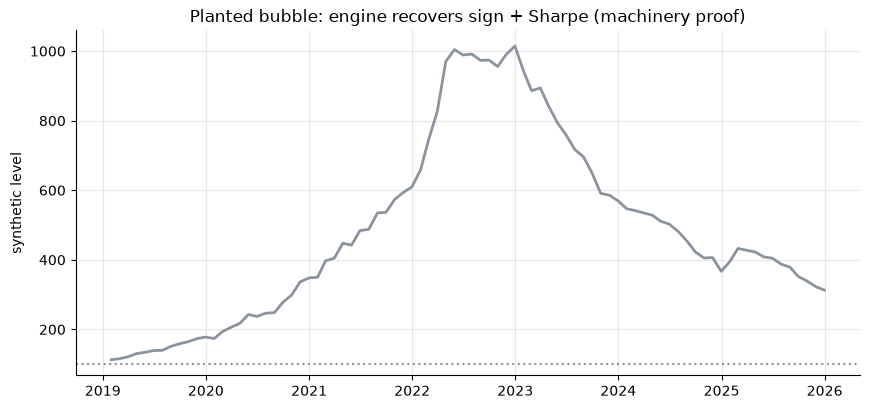

peak 1015 -> end 313  recovered CAGR +15.88%  Sharpe 0.81  maxDD -69.2%  sign_ok=1


In [5]:
syn = data.synthetic_bubble()
s = st.summarize(syn); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.plot(syn.index, syn.values, c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted bubble: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR ~+16%, Sharpe ~0.8, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything.

## 5 · The verdict

- **Signal `NONE`** — resale index CAGR 5.8% vs SPY 15.0%; annual excess -9.5%/yr, *t* = -1.05 (n=6); proxy alphas insignificant (WOSG *t*=-0.70, CFR *t*=+0.41). No robust *t* ≥ 2 anywhere in the watches' favour — and the point estimates lean negative.
- **Tradability `MIRAGE`** — gross +5.8% → net **-2.8%/yr** after a 20% dealer spread + carry; buyable proxy WOSG.L is β≈2.0 with a -77% drawdown. Illiquid, high-carry, bubble that round-tripped 2022–24.
- **Watches beat the S&P? `BUSTED`** — SPY wins CAGR, Sharpe (0.98 vs 0.34), drawdown and net-of-cost. The success stories are pre-March-2022 buyers who sold near the top: survivorship, not an asset class.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested end-2018, S&P index fund vs a watch flipper paying the real frictions (net CAGR from 4c). Capacity is the other wall: each physical flip is a bespoke, illiquid, ~20%-spread transaction — there is no scalable book.

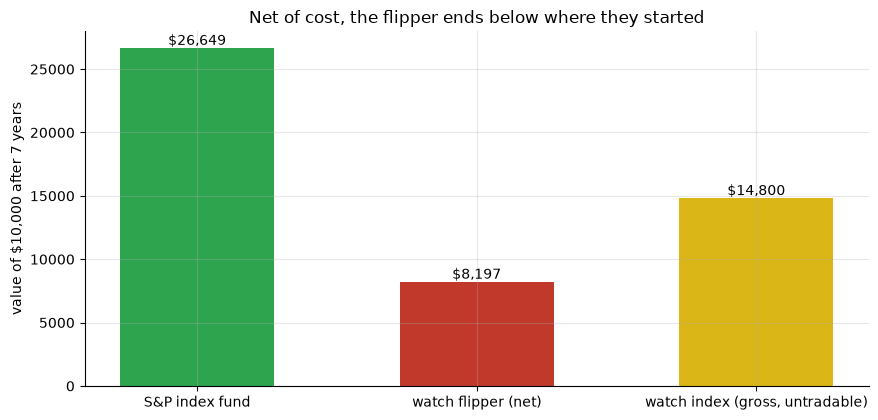

S&P index fund                     $    26,649  (+15.0%/yr)
watch flipper (net)                $     8,197  (-2.8%/yr)
watch index (gross, untradable)    $    14,800  (+5.8%/yr)


In [6]:
start=10_000.0; yrs_h=7
paths={'S&P index fund':R['spy_cagr_ye']/100, 'watch flipper (net)':R['carry_net']/100,
       'watch index (gross, untradable)':R['idx_cagr']/100}
fig, ax = plt.subplots(figsize=(9.0,4.3))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, AMBER]
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 7 years'); ax.set_title('Net of cost, the flipper ends below where they started')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: even the *gross, untradable* index trails the S&P; the *tradable* version (net of spread + carry) ends **below the starting stake**. And capacity is fatal — a watch flip is a one-off illiquid trade with a ~20% round-trip, the antithesis of a scalable strategy. There is no sizing or venue that turns this into an edge.

## 7 · Going further

- **Swap in the live index.** Replace the hardcoded series with the WatchCharts / Subdial feed (or the Morgan Stanley×WatchCharts quarterly levels) and re-run; the *t*-stats sharpen but the sign won't flip.
- **Per-reference dispersion.** The aggregate hides survivorship: test individual references (steel Daytona, Nautilus 5711, Royal Oak 15202) — the winners are a thin selected tail, the bias points *for* the claim, so correct for it.
- **The collectibles prior.** Dimson–Spaenjers and the emotional-assets literature: collectibles under-perform equities net of carry across the board ([docs/references.md](../docs/references.md)). Watches are not the exception.

*The reproducible core is offline and deterministic; the resale index is a **cited, approximate proxy** and the equity tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*